# Industrial IoT Anomaly Detection Analysis

This notebook performs comprehensive anomaly detection on industrial sensor data using:
- **Isolation Forest** (unsupervised)
- **Random Forest** (supervised)
- **XGBoost** (supervised)

All models are optimized using Optuna hyperparameter tuning.

https://www.kaggle.com/datasets/averkij/tennessee-eastman-process-simulation-dataset

## 1. Import Libraries

In [23]:
!pip install pyreadr

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score, precision_score, recall_score
)
import xgboost as xgb
import optuna
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances,
    plot_contour
)
import pyreadr

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load and Explore Data

In [27]:
# Load data
#df = pd.read_csv('../data/TEP_Faulty_Training')

result = pyreadr.read_r('../data/TEP_Faulty_Training.RData')
df = result['faulty_training']  # or 'faulty_training', etc.

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (5000000, 55)

Columns: ['faultNumber', 'simulationRun', 'sample', 'xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5', 'xmeas_6', 'xmeas_7', 'xmeas_8', 'xmeas_9', 'xmeas_10', 'xmeas_11', 'xmeas_12', 'xmeas_13', 'xmeas_14', 'xmeas_15', 'xmeas_16', 'xmeas_17', 'xmeas_18', 'xmeas_19', 'xmeas_20', 'xmeas_21', 'xmeas_22', 'xmeas_23', 'xmeas_24', 'xmeas_25', 'xmeas_26', 'xmeas_27', 'xmeas_28', 'xmeas_29', 'xmeas_30', 'xmeas_31', 'xmeas_32', 'xmeas_33', 'xmeas_34', 'xmeas_35', 'xmeas_36', 'xmeas_37', 'xmeas_38', 'xmeas_39', 'xmeas_40', 'xmeas_41', 'xmv_1', 'xmv_2', 'xmv_3', 'xmv_4', 'xmv_5', 'xmv_6', 'xmv_7', 'xmv_8', 'xmv_9', 'xmv_10', 'xmv_11']

First few rows:


,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,1,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,1,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,1,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,1,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,1,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


In [28]:
# Data info
print("Dataset Information:")
print("="*50)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 55 columns):
 #   Column         Dtype  
---  ------         -----  
 0   faultNumber    int32  
 1   simulationRun  float64
 2   sample         int32  
 3   xmeas_1        float64
 4   xmeas_2        float64
 5   xmeas_3        float64
 6   xmeas_4        float64
 7   xmeas_5        float64
 8   xmeas_6        float64
 9   xmeas_7        float64
 10  xmeas_8        float64
 11  xmeas_9        float64
 12  xmeas_10       float64
 13  xmeas_11       float64
 14  xmeas_12       float64
 15  xmeas_13       float64
 16  xmeas_14       float64
 17  xmeas_15       float64
 18  xmeas_16       float64
 19  xmeas_17       float64
 20  xmeas_18       float64
 21  xmeas_19       float64
 22  xmeas_20       float64
 23  xmeas_21       float64
 24  xmeas_22       float64
 25  xmeas_23       float64
 26  xmeas_24       float64
 27  xmeas_25       float64
 28  xmeas_26       float6

In [29]:
# Statistical summary
print("Statistical Summary:")
print("="*50)
df.describe()

Statistical Summary:


,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,...,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,1.050000e+01,2.505000e+02,2.505000e+02,2.613588e-01,3.663777e+03,4.506046e+03,9.370345e+00,2.690156e+01,4.236419e+01,2.723005e+03,...,5.431755e+01,3.043177e+01,6.324830e+01,2.295485e+01,3.992297e+01,3.807265e+01,4.643742e+01,5.060598e+01,4.194845e+01,1.884376e+01
std,5.766282e+00,1.443373e+02,1.443373e+02,1.495384e-01,4.316941e+01,1.110368e+02,3.646151e-01,2.320034e-01,3.172128e-01,7.599384e+01,...,5.258092e+00,2.048365e+01,7.400080e+00,1.108258e+01,1.293348e+01,2.949138e+00,2.358468e+00,1.759840e+01,1.001227e+01,5.176705e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,-4.735000e-03,3.327400e+03,3.540700e+03,6.639900e+00,2.538600e+01,3.965600e+01,2.413800e+03,...,3.118400e+01,-2.718600e-01,-4.893100e-03,-9.941000e-02,0.000000e+00,2.280100e+01,3.492300e+01,-3.635500e-01,-2.809500e-01,-5.327000e-03
25%,5.750000e+00,1.257500e+02,1.257500e+02,2.183000e-01,3.636500e+03,4.469000e+03,9.264200e+00,2.676000e+01,4.218100e+01,2.697600e+03,...,5.349700e+01,2.228000e+01,6.031400e+01,2.142300e+01,3.831300e+01,3.604900e+01,4.487800e+01,4.547900e+01,4.057500e+01,1.714300e+01
50%,1.050000e+01,2.505000e+02,2.505000e+02,2.511300e-01,3.663300e+03,4.508500e+03,9.355200e+00,2.690100e+01,4.234800e+01,2.705600e+03,...,5.397000e+01,2.521500e+01,6.149900e+01,2.212900e+01,3.996700e+01,3.815000e+01,4.633900e+01,4.806500e+01,4.120600e+01,1.829500e+01
75%,1.525000e+01,3.752500e+02,3.752500e+02,2.832100e-01,3.690200e+03,4.548000e+03,9.456800e+00,2.704300e+01,4.252400e+01,2.715000e+03,...,5.444300e+01,2.879700e+01,6.284100e+01,2.273800e+01,4.150700e+01,3.999100e+01,4.803100e+01,5.188700e+01,4.194900e+01,1.953700e+01
max,2.000000e+01,5.000000e+02,5.000000e+02,1.017500e+00,3.906700e+03,5.175800e+03,1.224000e+01,2.848600e+01,4.465300e+01,3.000500e+03,...,1.000000e+02,1.001900e+02,1.000200e+02,1.001100e+02,9.752800e+01,5.312100e+01,5.998000e+01,1.005200e+02,1.003200e+02,1.000100e+02


In [30]:
# Check for missing values
print("Missing Values:")
print("="*50)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df if len(missing_df) > 0 else "No missing values found!")

Missing Values:
No missing values found!


In [31]:
# Target variable distribution
print("Anomaly Distribution:")
print("="*50)
print(df['faultNumber '].value_counts())
print(f"\nAnomaly Rate: {(df['anomaly_flag'].sum() / len(df)) * 100:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df['anomaly_flag'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Anomaly Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Anomaly Flag (0=Normal, 1=Anomaly)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Normal', 'Anomaly'], rotation=0)

# Pie chart
df['anomaly_flag'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                        labels=['Normal', 'Anomaly'], colors=['green', 'red'])
axes[1].set_title('Anomaly Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Anomaly Distribution:


KeyError: 'faultNumber '

## 3. Data Cleaning

In [15]:
# Create a copy for cleaning
df_clean = df.copy()

print(f"Original shape: {df_clean.shape}")

# Convert timestamp to datetime if present
if 'timestamp' in df_clean.columns:
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
    print("\nTimestamp converted to datetime")

# Handle missing values
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns
print(f"\nNumeric columns: {len(numeric_columns)}")

# Fill numeric NaNs with median (robust to outliers)
for col in numeric_columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Filled {col} NaNs with median: {median_val:.2f}")

# Fill categorical NaNs with mode
categorical_columns = df_clean.select_dtypes(include=['object']).columns
for col in categorical_columns:
    if col != 'timestamp' and df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"Filled {col} NaNs with mode: {mode_val}")

# Remove duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f"\nRemoved {duplicates} duplicate rows")
else:
    print("\nNo duplicates found")

print(f"\nCleaned shape: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Original shape: (100000, 10)

Timestamp converted to datetime

Numeric columns: 8

No duplicates found

Cleaned shape: (100000, 10)
Rows removed: 0


## 4. Feature Engineering and Selection

In [16]:
# Define feature columns (exclude target and non-feature columns)
exclude_cols = ['timestamp', 'anomaly_flag', 'failure_type']
feature_cols = [col for col in df_clean.columns if col not in exclude_cols]

# Select only numeric features
numeric_features = df_clean[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"Selected features for modeling: {len(numeric_features)}")
print(numeric_features)

Selected features for modeling: 7
['machine_id', 'temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption', 'machine_status']


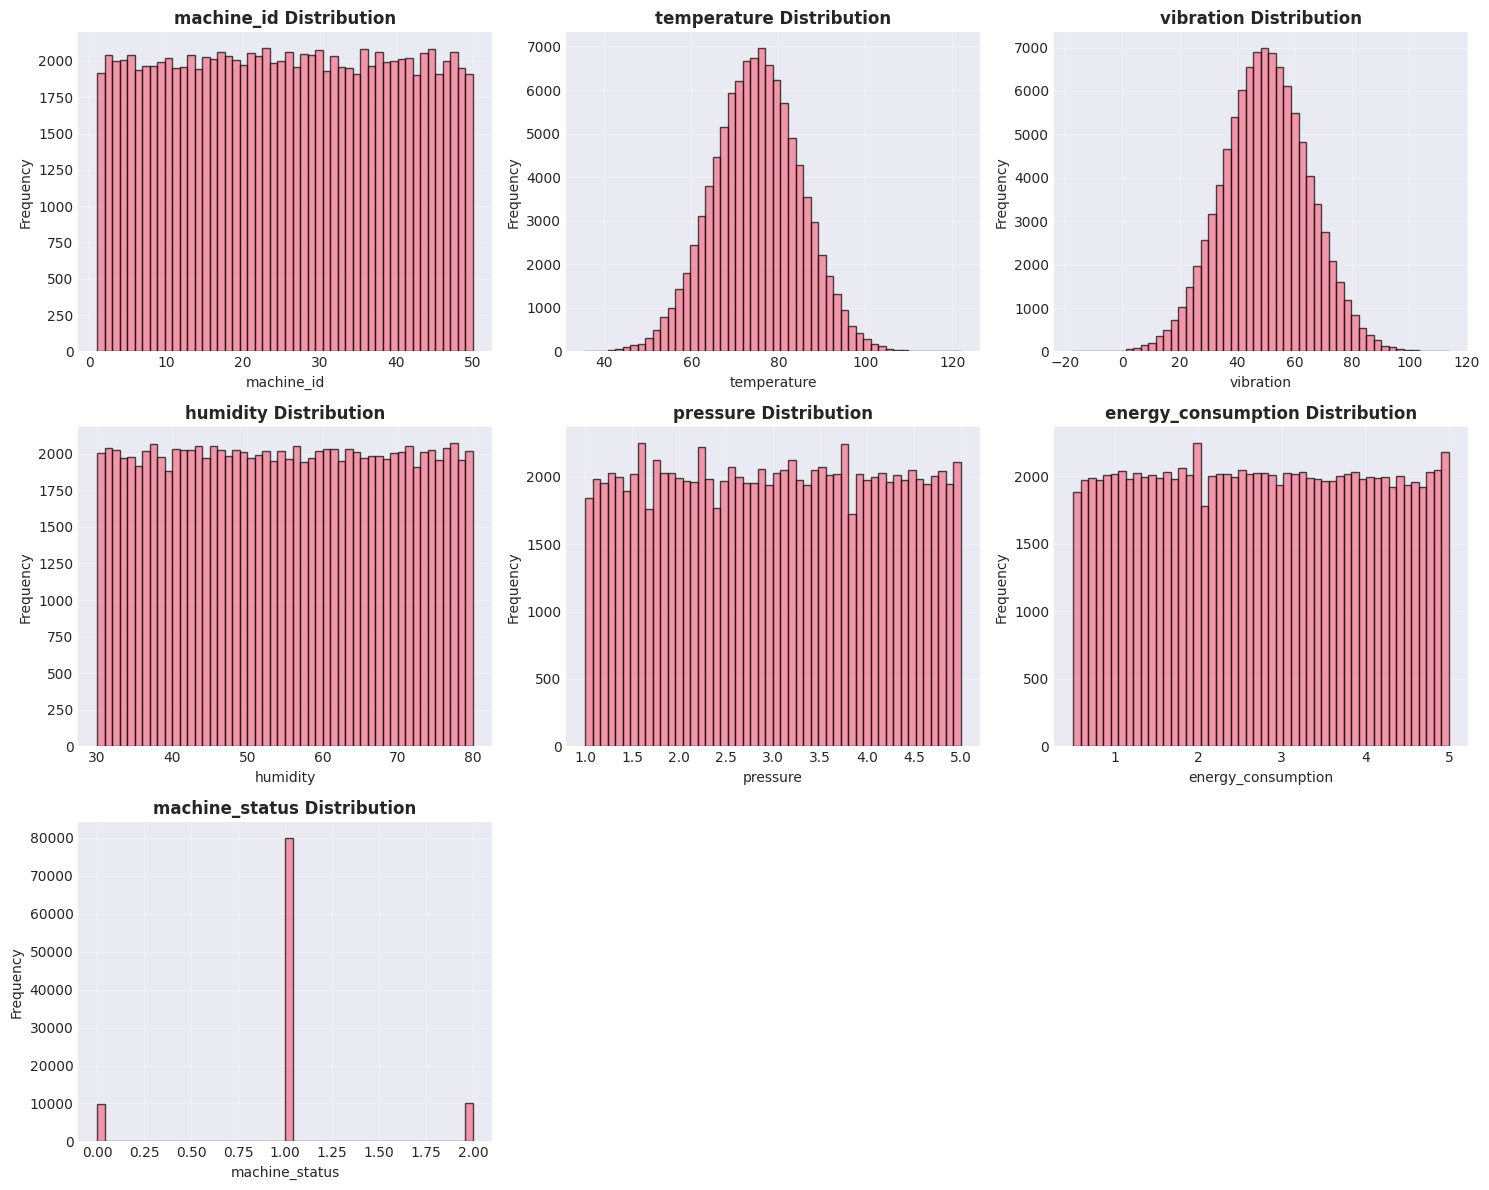

In [17]:
# Feature distributions
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(numeric_features):
    axes[idx].hist(df_clean[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} Distribution', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

# Hide extra subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 5. Correlation Analysis

Sensor features for correlation analysis: ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption', 'machine_status']
Number of features: 6

Basic statistics:
         temperature      vibration       humidity       pressure  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean       75.015625      50.012270      54.995401       3.000405   
std        10.031884      14.985444      14.437960       1.152399   
min        35.550000     -17.090000      30.000000       1.000000   
25%        68.267500      39.970000      42.520000       2.000000   
50%        75.060000      49.960000      54.980000       3.010000   
75%        81.750000      60.100000      67.500000       4.000000   
max       121.940000     113.800000      80.000000       5.000000   

       energy_consumption  machine_status  
count       100000.000000   100000.000000  
mean             2.747064        1.002050  
std              1.297865        0.446193  
min              0.500000 

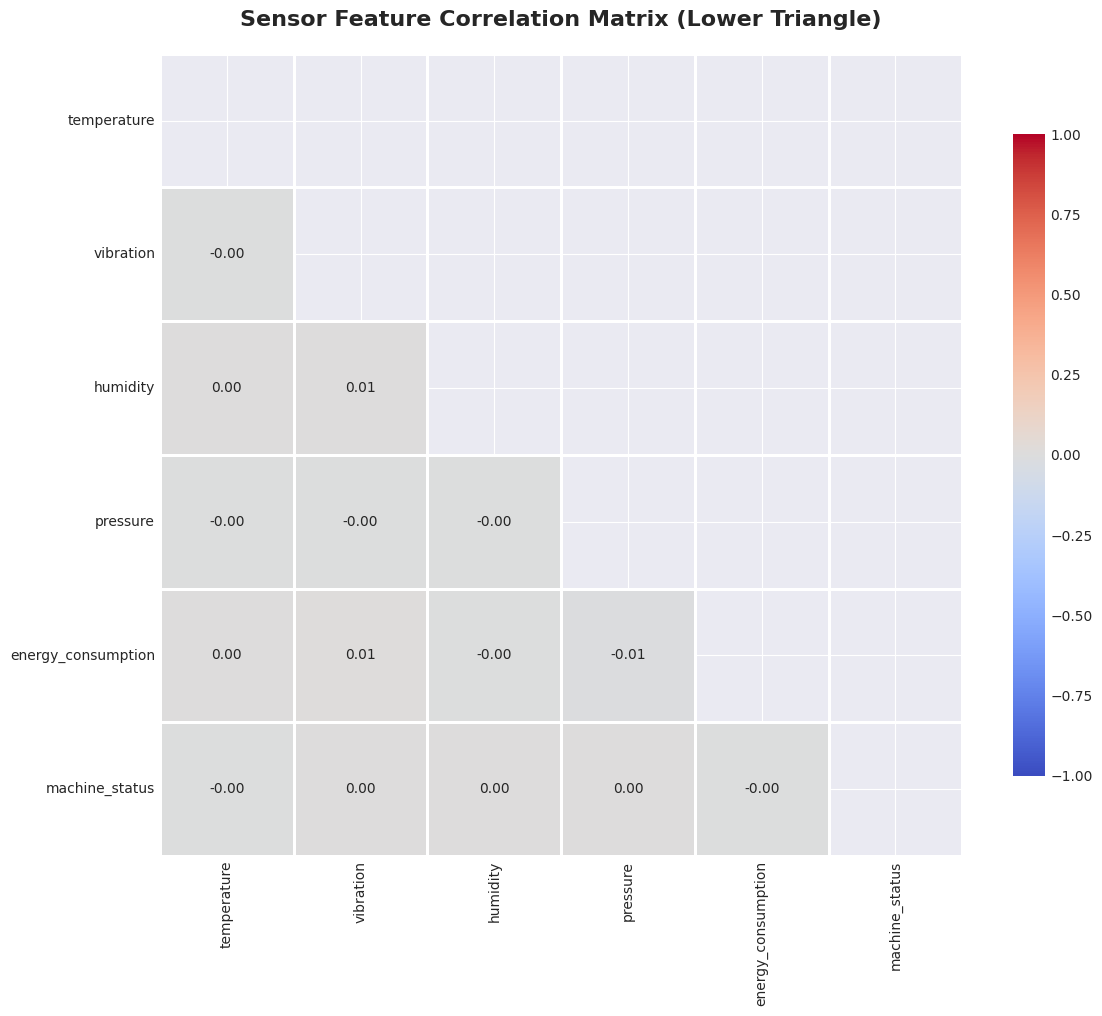


Highly Correlated Features (|correlation| > 0.7):
No highly correlated feature pairs found (threshold > 0.7)

Moderately Correlated Features (0.5 < |correlation| < 0.7):
No moderately correlated feature pairs found


In [21]:
# Properly select ONLY numeric sensor features for correlation
# Exclude: timestamp, IDs, targets, categorical columns
exclude_for_correlation = [
    'timestamp', 'machine_id', 'anomaly_flag', 
    'predicted_remaining_life', 'downtime_risk', 'maintenance_required',
    'failure_type'  # categorical
]

# Select numeric sensor columns only
sensor_features = [col for col in df_clean.columns if col not in exclude_for_correlation]
sensor_features = df_clean[sensor_features].select_dtypes(include=[np.number]).columns.tolist()

print(f"Sensor features for correlation analysis: {sensor_features}")
print(f"Number of features: {len(sensor_features)}")
print(f"\nBasic statistics:")
print(df_clean[sensor_features].describe())

# Calculate correlation matrix
correlation_matrix = df_clean[sensor_features].corr()

print(f"\nCorrelation matrix shape: {correlation_matrix.shape}")
print(f"Correlation range: [{correlation_matrix.min().min():.3f}, {correlation_matrix.max().max():.3f}]")

# Create mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Create figure
plt.figure(figsize=(12, 10))

# Plot heatmap with triangular mask
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1
)

plt.title('Sensor Feature Correlation Matrix (Lower Triangle)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print high correlations
print("\nHighly Correlated Features (|correlation| > 0.7):")
print("="*50)
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr:
    for feat1, feat2, corr in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"{feat1} <-> {feat2}: {corr:.3f}")
else:
    print("No highly correlated feature pairs found (threshold > 0.7)")

# Also print moderate correlations
print("\nModerately Correlated Features (0.5 < |correlation| < 0.7):")
print("="*50)
moderate_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if 0.5 < abs(correlation_matrix.iloc[i, j]) < 0.7:
            moderate_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if moderate_corr:
    for feat1, feat2, corr in sorted(moderate_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"{feat1} <-> {feat2}: {corr:.3f}")
else:
    print("No moderately correlated feature pairs found")

## 6. Prepare Data for Modeling

In [19]:
# Prepare features and target
X = df_clean[numeric_features].values
y = df_clean['anomaly_flag'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nClass distribution:")
print(f"Normal (0): {(y == 0).sum()} ({(y == 0).sum() / len(y) * 100:.2f}%)")
print(f"Anomaly (1): {(y == 1).sum()} ({(y == 1).sum() / len(y) * 100:.2f}%)")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled using StandardScaler")

Feature matrix shape: (100000, 7)
Target vector shape: (100000,)

Class distribution:
Normal (0): 91084 (91.08%)
Anomaly (1): 8916 (8.92%)

Train set: (80000, 7)
Test set: (20000, 7)

Features scaled using StandardScaler


## 7. Model Training with Optuna Optimization

### 7.1 Isolation Forest (Unsupervised)

In [20]:
def objective_isolation_forest(trial):
    """
    Optuna objective for Isolation Forest
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_samples': trial.suggest_int('max_samples', 100, 1000),
        'contamination': trial.suggest_float('contamination', 0.01, 0.3),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42
    }
    
    model = IsolationForest(**params)
    
    # Fit on training data
    model.fit(X_train_scaled)
    
    # Predict (-1 for anomaly, 1 for normal) -> convert to (1 for anomaly, 0 for normal)
    y_pred = model.predict(X_test_scaled)
    y_pred_binary = np.where(y_pred == -1, 1, 0)
    
    # Calculate F1 score
    f1 = f1_score(y_test, y_pred_binary)
    
    return f1

# Run optimization
print("Starting Isolation Forest optimization...")
study_if = optuna.create_study(direction='maximize', study_name='IsolationForest')
study_if.optimize(objective_isolation_forest, n_trials=50, show_progress_bar=True)

print(f"\nBest F1 Score: {study_if.best_value:.4f}")
print(f"Best Parameters: {study_if.best_params}")

# Train final model with best parameters
best_if = IsolationForest(**study_if.best_params, random_state=42)
best_if.fit(X_train_scaled)
y_pred_if = best_if.predict(X_test_scaled)
y_pred_if_binary = np.where(y_pred_if == -1, 1, 0)

[I 2025-11-11 18:16:12,467] A new study created in memory with name: IsolationForest


Starting Isolation Forest optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-11 18:16:13,841] Trial 0 finished with value: 0.20153061224489793 and parameters: {'n_estimators': 148, 'max_samples': 291, 'contamination': 0.06691234023065327, 'max_features': 0.9165331784564537, 'bootstrap': True}. Best is trial 0 with value: 0.20153061224489793.
[I 2025-11-11 18:16:16,328] Trial 1 finished with value: 0.28004125838060856 and parameters: {'n_estimators': 223, 'max_samples': 674, 'contamination': 0.1051614290926767, 'max_features': 0.5677563606907492, 'bootstrap': False}. Best is trial 1 with value: 0.28004125838060856.
[I 2025-11-11 18:16:17,212] Trial 2 finished with value: 0.23610654390003286 and parameters: {'n_estimators': 75, 'max_samples': 971, 'contamination': 0.06300778577772119, 'max_features': 0.72633100859319, 'bootstrap': False}. Best is trial 1 with value: 0.28004125838060856.
[I 2025-11-11 18:16:18,888] Trial 3 finished with value: 0.2872438054450902 and parameters: {'n_estimators': 175, 'max_samples': 849, 'contamination': 0.237310745157667

### 7.2 Random Forest Classifier

In [ ]:
def objective_random_forest(trial):
    """
    Optuna objective for Random Forest
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42
    }
    
    model = RandomForestClassifier(**params)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate F1 score
    f1 = f1_score(y_test, y_pred)
    
    return f1

# Run optimization
print("Starting Random Forest optimization...")
study_rf = optuna.create_study(direction='maximize', study_name='RandomForest')
study_rf.optimize(objective_random_forest, n_trials=50, show_progress_bar=True)

print(f"\nBest F1 Score: {study_rf.best_value:.4f}")
print(f"Best Parameters: {study_rf.best_params}")

# Train final model with best parameters
best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42)
best_rf.fit(X_train_scaled, y_train)
y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_rf_proba = best_rf.predict_proba(X_test_scaled)[:, 1]

### 7.3 XGBoost Classifier

In [ ]:
def objective_xgboost(trial):
    """
    Optuna objective for XGBoost
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0),
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    
    model = xgb.XGBClassifier(**params, use_label_encoder=False)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate F1 score
    f1 = f1_score(y_test, y_pred)
    
    return f1

# Run optimization
print("Starting XGBoost optimization...")
study_xgb = optuna.create_study(direction='maximize', study_name='XGBoost')
study_xgb.optimize(objective_xgboost, n_trials=50, show_progress_bar=True)

print(f"\nBest F1 Score: {study_xgb.best_value:.4f}")
print(f"Best Parameters: {study_xgb.best_params}")

# Train final model with best parameters
best_xgb = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, use_label_encoder=False)
best_xgb.fit(X_train_scaled, y_train)
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_pred_xgb_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

## 8. Model Evaluation and Comparison

In [ ]:
# Calculate metrics for all models
models_results = {
    'Isolation Forest': {
        'predictions': y_pred_if_binary,
        'accuracy': accuracy_score(y_test, y_pred_if_binary),
        'precision': precision_score(y_test, y_pred_if_binary),
        'recall': recall_score(y_test, y_pred_if_binary),
        'f1': f1_score(y_test, y_pred_if_binary)
    },
    'Random Forest': {
        'predictions': y_pred_rf,
        'probabilities': y_pred_rf_proba,
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'precision': precision_score(y_test, y_pred_rf),
        'recall': recall_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf),
        'roc_auc': roc_auc_score(y_test, y_pred_rf_proba)
    },
    'XGBoost': {
        'predictions': y_pred_xgb,
        'probabilities': y_pred_xgb_proba,
        'accuracy': accuracy_score(y_test, y_pred_xgb),
        'precision': precision_score(y_test, y_pred_xgb),
        'recall': recall_score(y_test, y_pred_xgb),
        'f1': f1_score(y_test, y_pred_xgb),
        'roc_auc': roc_auc_score(y_test, y_pred_xgb_proba)
    }
}

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Isolation Forest', 'Random Forest', 'XGBoost'],
    'Accuracy': [models_results['Isolation Forest']['accuracy'],
                 models_results['Random Forest']['accuracy'],
                 models_results['XGBoost']['accuracy']],
    'Precision': [models_results['Isolation Forest']['precision'],
                  models_results['Random Forest']['precision'],
                  models_results['XGBoost']['precision']],
    'Recall': [models_results['Isolation Forest']['recall'],
               models_results['Random Forest']['recall'],
               models_results['XGBoost']['recall']],
    'F1-Score': [models_results['Isolation Forest']['f1'],
                 models_results['Random Forest']['f1'],
                 models_results['XGBoost']['f1']],
    'ROC-AUC': [np.nan,
                models_results['Random Forest']['roc_auc'],
                models_results['XGBoost']['roc_auc']]
})

print("\nModel Comparison:")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualize metrics comparison
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=ax, rot=0, width=0.8
)
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim([0, 1.1])
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Confusion Matrices

In [ ]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, results) in enumerate(models_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', 
        ax=axes[idx], cbar=True,
        xticklabels=['Normal', 'Anomaly'],
        yticklabels=['Normal', 'Anomaly']
    )
    
    axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.show()

## 10. ROC Curves

In [ ]:
# Plot ROC curves for supervised models
plt.figure(figsize=(10, 8))

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_proba)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {models_results["Random Forest"]["roc_auc"]:.3f})', 
         linewidth=2)

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb_proba)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {models_results["XGBoost"]["roc_auc"]:.3f})', 
         linewidth=2)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Precision-Recall Curves

In [ ]:
# Plot Precision-Recall curves
plt.figure(figsize=(10, 8))

# Random Forest PR
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_rf_proba)
plt.plot(recall_rf, precision_rf, label=f'Random Forest', linewidth=2)

# XGBoost PR
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_xgb_proba)
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost', linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Feature Importance Analysis

In [ ]:
# Plot feature importance for supervised models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'feature': numeric_features,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

axes[0].barh(rf_importance['feature'][:15], rf_importance['importance'][:15])
axes[0].set_xlabel('Importance', fontsize=11)
axes[0].set_title('Random Forest - Top 15 Features', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'feature': numeric_features,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

axes[1].barh(xgb_importance['feature'][:15], xgb_importance['importance'][:15], color='orange')
axes[1].set_xlabel('Importance', fontsize=11)
axes[1].set_title('XGBoost - Top 15 Features', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 10 Features by Model:")
print("="*80)
print("\nRandom Forest:")
print(rf_importance.head(10).to_string(index=False))
print("\nXGBoost:")
print(xgb_importance.head(10).to_string(index=False))

## 13. Optimization History Visualization

In [ ]:
# Plot optimization history for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

studies = [
    (study_if, 'Isolation Forest', axes[0]),
    (study_rf, 'Random Forest', axes[1]),
    (study_xgb, 'XGBoost', axes[2])
]

for study, name, ax in studies:
    trials_df = study.trials_dataframe()
    ax.plot(trials_df['number'], trials_df['value'], marker='o', linestyle='-', alpha=0.6)
    ax.axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
    ax.set_xlabel('Trial Number', fontsize=10)
    ax.set_ylabel('F1 Score', fontsize=10)
    ax.set_title(f'{name}\nOptimization History', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Hyperparameter Importance

In [ ]:
# Plot parameter importance for each model
fig = plt.figure(figsize=(18, 5))

# Isolation Forest
ax1 = fig.add_subplot(131)
optuna.visualization.matplotlib.plot_param_importances(study_if, ax=ax1)
ax1.set_title('Isolation Forest\nParameter Importance', fontsize=12, fontweight='bold')

# Random Forest
ax2 = fig.add_subplot(132)
optuna.visualization.matplotlib.plot_param_importances(study_rf, ax=ax2)
ax2.set_title('Random Forest\nParameter Importance', fontsize=12, fontweight='bold')

# XGBoost
ax3 = fig.add_subplot(133)
optuna.visualization.matplotlib.plot_param_importances(study_xgb, ax=ax3)
ax3.set_title('XGBoost\nParameter Importance', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 15. Classification Reports

In [ ]:
# Print detailed classification reports
for model_name, results in models_results.items():
    print(f"\n{'='*80}")
    print(f"{model_name} - Classification Report")
    print('='*80)
    print(classification_report(y_test, results['predictions'], 
                                target_names=['Normal', 'Anomaly']))

## 16. Best Model Summary

In [ ]:
# Determine best model based on F1 score
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
best_f1 = comparison_df['F1-Score'].max()

print("\n" + "="*80)
print("BEST MODEL SUMMARY")
print("="*80)
print(f"\nBest Model: {best_model_name}")
print(f"F1-Score: {best_f1:.4f}")
print(f"\nDetailed Metrics:")
best_metrics = comparison_df[comparison_df['Model'] == best_model_name].iloc[0]
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    value = best_metrics[metric]
    if not pd.isna(value):
        print(f"  {metric}: {value:.4f}")

# Get best hyperparameters
if best_model_name == 'Isolation Forest':
    best_params = study_if.best_params
elif best_model_name == 'Random Forest':
    best_params = study_rf.best_params
else:
    best_params = study_xgb.best_params

print(f"\nOptimized Hyperparameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print("\n" + "="*80)

## 17. Save Results

In [ ]:
# Save comparison results to CSV
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("Model comparison results saved to: model_comparison_results.csv")

# Save best parameters
best_params_df = pd.DataFrame([
    {'Model': 'Isolation Forest', **study_if.best_params},
    {'Model': 'Random Forest', **study_rf.best_params},
    {'Model': 'XGBoost', **study_xgb.best_params}
])
best_params_df.to_csv('best_hyperparameters.csv', index=False)
print("Best hyperparameters saved to: best_hyperparameters.csv")

print("\n✅ Analysis complete!")